In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

# Models
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/taeefnajib/used-car-price-prediction-dataset/used_cars.csv


In [4]:
file_path = "/kaggle/input/datasets/taeefnajib/used-car-price-prediction-dataset/used_cars.csv"

df = pd.read_csv(file_path)

df.head()


,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [5]:
df.shape

(4009, 12)

In [6]:
print("Dataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   brand         4009 non-null   object
 1   model         4009 non-null   object
 2   model_year    4009 non-null   int64 
 3   milage        4009 non-null   object
 4   fuel_type     3839 non-null   object
 5   engine        4009 non-null   object
 6   transmission  4009 non-null   object
 7   ext_col       4009 non-null   object
 8   int_col       4009 non-null   object
 9   accident      3896 non-null   object
 10  clean_title   3413 non-null   object
 11  price         4009 non-null   object
dtypes: int64(1), object(11)
memory usage: 376.0+ KB

Missing Values:
brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title   

In [7]:
# Create a copy
df_clean = df.copy()

# Remove $ and commas from price
df_clean['price'] = (
    df_clean['price']
    .str.replace('$', '', regex=False)
    .str.replace(',', '', regex=False)
    .astype(float)
)

# Remove commas and ' mi.' from milage
df_clean['milage'] = (
    df_clean['milage']
    .str.replace(',', '', regex=False)
    .str.replace(' mi.', '', regex=False)
    .astype(float)
)

print("Price dtype:", df_clean['price'].dtype)
print("Milage dtype:", df_clean['milage'].dtype)

df_clean[['price', 'milage']].head()

Price dtype: float64
Milage dtype: float64


,price,milage
0,10300.0,51000.0
1,38005.0,34742.0
2,54598.0,22372.0
3,15500.0,88900.0
4,34999.0,9835.0


In [8]:
# Fill missing fuel type
df_clean["fuel_type"] = df_clean["fuel_type"].fillna("Unknown")

# Fill missing accident information
df_clean["accident"] = df_clean["accident"].fillna("Unknown")

# Fill missing clean_title
df_clean["clean_title"] = df_clean["clean_title"].fillna("Unknown")

# Check remaining missing values
print(df_clean.isnull().sum())

brand           0
model           0
model_year      0
milage          0
fuel_type       0
engine          0
transmission    0
ext_col         0
int_col         0
accident        0
clean_title     0
price           0
dtype: int64


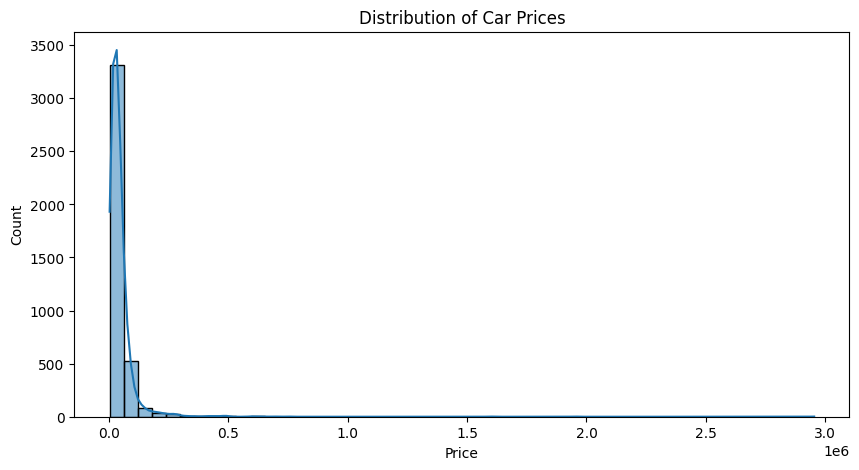

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["price"], bins=50, kde=True)

plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Count")

plt.show()

In [10]:
print(df_clean["price"].describe())

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64


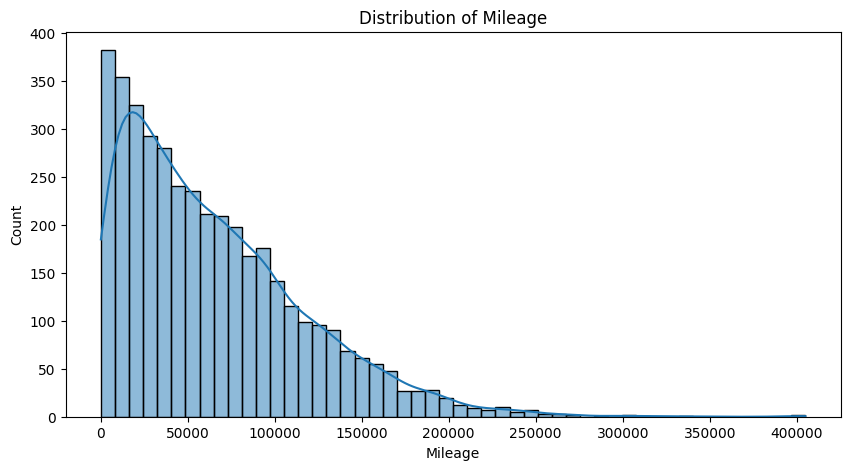

In [11]:
plt.figure(figsize=(10,5))
sns.histplot(df_clean["milage"], bins=50, kde=True)

plt.title("Distribution of Mileage")
plt.xlabel("Mileage")
plt.ylabel("Count")

plt.show()

In [12]:
print(df_clean["milage"].describe())

count      4009.000000
mean      64717.551010
std       52296.599459
min         100.000000
25%       23044.000000
50%       52775.000000
75%       94100.000000
max      405000.000000
Name: milage, dtype: float64


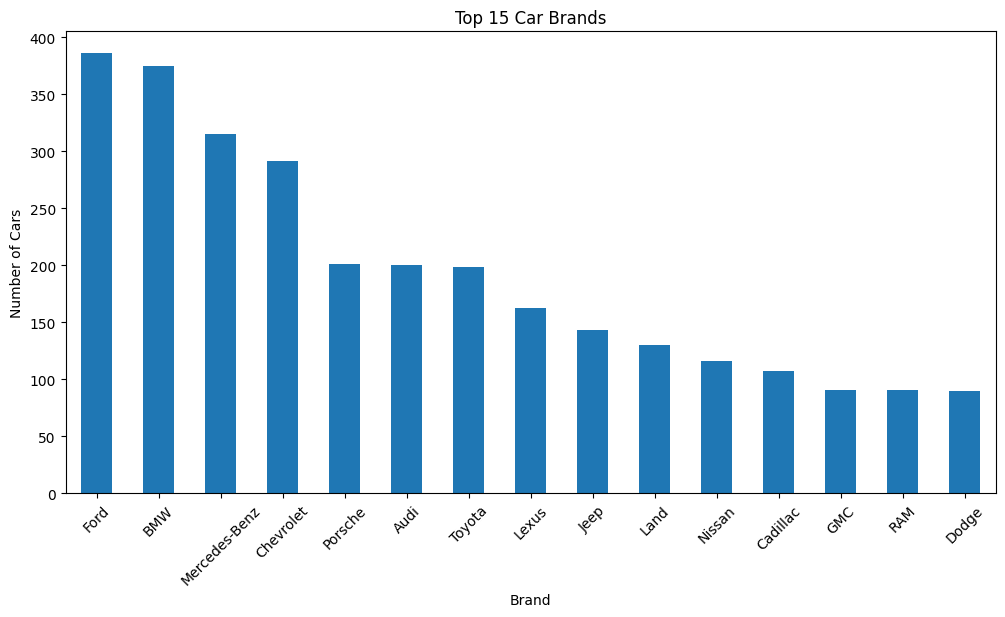

In [13]:
plt.figure(figsize=(12,6))

df_clean["brand"].value_counts().head(15).plot(kind="bar")

plt.title("Top 15 Car Brands")
plt.xlabel("Brand")
plt.ylabel("Number of Cars")

plt.xticks(rotation=45)
plt.show()

In [14]:
df_clean["brand"].value_counts().head(15)

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Nissan           116
Cadillac         107
GMC               91
RAM               91
Dodge             90
Name: count, dtype: int64

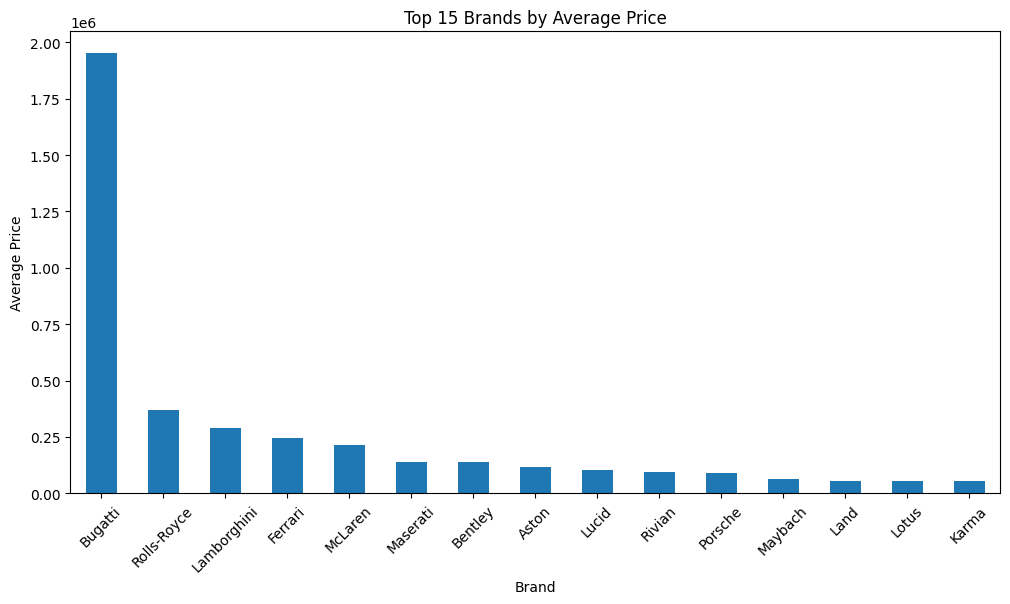

brand
Bugatti        1.950995e+06
Rolls-Royce    3.709927e+05
Lamborghini    2.912338e+05
Ferrari        2.437907e+05
McLaren        2.134575e+05
Maserati       1.405825e+05
Bentley        1.375535e+05
Aston          1.151996e+05
Lucid          1.019663e+05
Rivian         9.313818e+04
Porsche        8.875130e+04
Maybach        6.425000e+04
Land           5.576406e+04
Lotus          5.481250e+04
Karma          5.325000e+04
Name: price, dtype: float64

In [15]:
top_price_brands = (
    df_clean.groupby("brand")["price"]
    .mean()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
top_price_brands.plot(kind="bar")

plt.title("Top 15 Brands by Average Price")
plt.xlabel("Brand")
plt.ylabel("Average Price")

plt.xticks(rotation=45)
plt.show()
top_price_brands

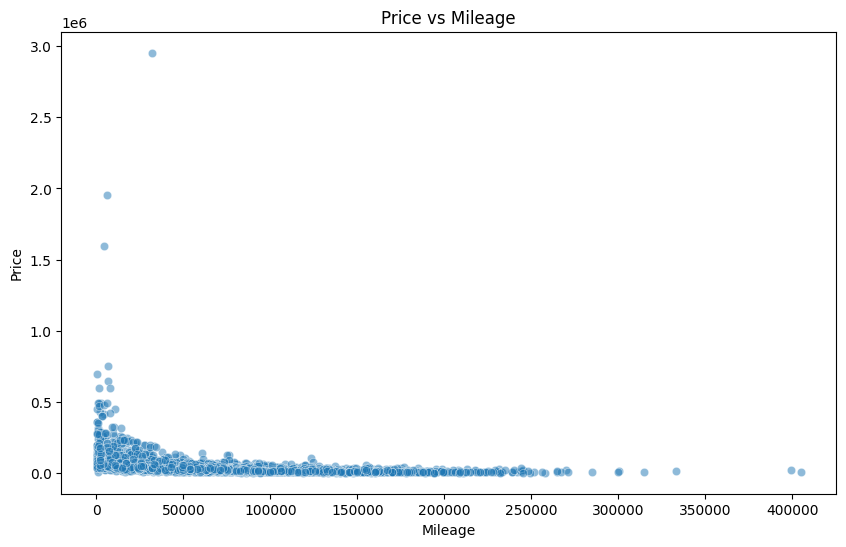

In [16]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="milage",
    y="price",
    data=df_clean,
    alpha=0.5
)

plt.title("Price vs Mileage")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()

In [17]:
print(
    "Correlation between Mileage and Price:",
    df_clean["milage"].corr(df_clean["price"])
)

Correlation between Mileage and Price: -0.305528068928181


In [18]:
# Create car age feature

CURRENT_YEAR = 2025

df_clean["car_age"] = CURRENT_YEAR - df_clean["model_year"]

# Check

df_clean[["model_year", "car_age"]].head()

,model_year,car_age
0,2013,12
1,2021,4
2,2022,3
3,2015,10
4,2021,4


In [19]:
print(df_clean["car_age"].describe())

count    4009.000000
mean        9.484410
std         6.104816
min         1.000000
25%         5.000000
50%         8.000000
75%        13.000000
max        51.000000
Name: car_age, dtype: float64


In [20]:
# Features and Target

X = df_clean.drop(
    columns=["price"]
)

y = df_clean["price"]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X Shape: (4009, 12)
y Shape: (4009,)

Features:
['brand', 'model', 'model_year', 'milage', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title', 'car_age']


In [21]:
# Numerical and categorical columns

num_cols = [
    "model_year",
    "milage",
    "car_age"
]

cat_cols = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]

# Preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

print("Preprocessor created successfully")

Preprocessor created successfully


In [22]:
# Split dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (3207, 12)
Testing Shape : (802, 12)


In [23]:
# Linear Regression Pipeline

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

# Train model
lr_pipeline.fit(X_train, y_train)

# Predictions
y_pred_lr = lr_pipeline.predict(X_test)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [24]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Evaluation

rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression Results")
print("-" * 30)
print("RMSE :", rmse)
print("R² Score :", r2)

Linear Regression Results
------------------------------
RMSE : 137975.81519487634
R² Score : 0.06860444699374002


In [25]:
results_lr = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred_lr
})

results_lr.head(10)

,Actual Price,Predicted Price
0,28000.0,26747.043845
1,5900.0,15344.045098
2,41000.0,44581.936571
3,40250.0,41410.261631
4,77999.0,59763.286310
5,35899.0,35046.488098
6,36000.0,29384.800876
7,47214.0,52896.410153
8,30900.0,12124.156102
9,11000.0,19102.818544


In [26]:
# Decision Tree Pipeline

dt_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(
        max_depth=10,
        random_state=42
    ))
])

# Train

dt_pipeline.fit(X_train, y_train)

# Predict

y_pred_dt = dt_pipeline.predict(X_test)

print("Decision Tree Trained Successfully")

Decision Tree Trained Successfully


In [27]:
# Decision Tree Evaluation

rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("Decision Tree Results")
print("-" * 30)
print("RMSE :", rmse_dt)
print("R² Score :", r2_dt)

Decision Tree Results
------------------------------
RMSE : 137527.52993219555
R² Score : 0.07464684823370227


In [28]:
comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Decision Tree"],
    "RMSE": [rmse, rmse_dt],
    "R2 Score": [r2, r2_dt]
})

comparison

,Model,RMSE,R2 Score
0,Linear Regression,137975.815195,0.068604
1,Decision Tree,137527.529932,0.074647


In [29]:
# Random Forest Pipeline

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

# Train model

rf_pipeline.fit(X_train, y_train)

# Predict

y_pred_rf = rf_pipeline.predict(X_test)

print("Random Forest Trained Successfully")

Random Forest Trained Successfully


In [30]:
# Random Forest Evaluation

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("-" * 30)
print("RMSE :", rmse_rf)
print("R² Score :", r2_rf)

Random Forest Results
------------------------------
RMSE : 134940.09139513355
R² Score : 0.10913843428005043


In [31]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "RMSE": [
        rmse,
        rmse_dt,
        rmse_rf
    ],
    "R2 Score": [
        r2,
        r2_dt,
        r2_rf
    ]
})

comparison.sort_values("R2 Score", ascending=False)

,Model,RMSE,R2 Score
2,Random Forest,134940.091395,0.109138
1,Decision Tree,137527.529932,0.074647
0,Linear Regression,137975.815195,0.068604


In [32]:
# Extract horsepower

df_clean["horsepower"] = (
    df_clean["engine"]
    .str.extract(r'(\d+\.?\d*)HP')[0]
)

# Extract engine size in liters

df_clean["engine_size"] = (
    df_clean["engine"]
    .str.extract(r'(\d+\.?\d*)L')[0]
)

# Convert to numeric

df_clean["horsepower"] = pd.to_numeric(
    df_clean["horsepower"],
    errors="coerce"
)

df_clean["engine_size"] = pd.to_numeric(
    df_clean["engine_size"],
    errors="coerce"
)

print(df_clean[["engine", "horsepower", "engine_size"]].head())

                                              engine  horsepower  engine_size
0  300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...       300.0          3.7
1                               3.8L V6 24V GDI DOHC         NaN          3.8
2                                     3.5 Liter DOHC         NaN          NaN
3  354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...       354.0          3.5
4                         2.0L I4 16V GDI DOHC Turbo         NaN          2.0


In [33]:
print(df_clean[["horsepower", "engine_size"]].isnull().sum())

horsepower     808
engine_size    377
dtype: int64


In [34]:
df_clean[["engine", "horsepower", "engine_size"]].head()

,engine,horsepower,engine_size
0,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,300.0,3.7
1,3.8L V6 24V GDI DOHC,NaN,3.8
2,3.5 Liter DOHC,NaN,NaN
3,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,354.0,3.5
4,2.0L I4 16V GDI DOHC Turbo,NaN,2.0


In [35]:
# Fill missing values with median

df_clean["horsepower"] = df_clean["horsepower"].fillna(
    df_clean["horsepower"].median()
)

df_clean["engine_size"] = df_clean["engine_size"].fillna(
    df_clean["engine_size"].median()
)

print(df_clean[["horsepower", "engine_size"]].isnull().sum())

horsepower     0
engine_size    0
dtype: int64


In [36]:
print(df_clean[["horsepower", "engine_size"]].describe())

        horsepower  engine_size
count  4009.000000  4009.000000
mean    327.730856     3.689386
std     109.604837     1.355937
min      70.000000     0.650000
25%     268.000000     2.700000
50%     310.000000     3.500000
75%     381.000000     4.600000
max    1020.000000     8.400000


In [40]:
# Rebuild feature matrix

X = df_clean.drop(columns=["price"])

y = df_clean["price"]

# Updated numerical columns

num_cols = [
    "model_year",
    "milage",
    "car_age",
    "horsepower",
    "engine_size"
]

# Updated categorical columns

cat_cols = [
    "brand",
    "model",
    "fuel_type",
    "engine",
    "transmission",
    "ext_col",
    "int_col",
    "accident",
    "clean_title"
]

# Updated preprocessor

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols)
    ]
)

print("Updated preprocessor created")

Updated preprocessor created


In [41]:
# Train-test split again

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3207, 14)
(802, 14)


In [42]:
# Random Forest with engineered features

rf_pipeline_v2 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

# Train
rf_pipeline_v2.fit(X_train, y_train)

# Predict
y_pred_rf_v2 = rf_pipeline_v2.predict(X_test)

print("Improved Random Forest Trained Successfully")

Improved Random Forest Trained Successfully


In [43]:
# Evaluation

rmse_rf_v2 = np.sqrt(mean_squared_error(y_test, y_pred_rf_v2))
r2_rf_v2 = r2_score(y_test, y_pred_rf_v2)

print("Improved Random Forest Results")
print("-" * 30)
print("RMSE :", rmse_rf_v2)
print("R² Score :", r2_rf_v2)

Improved Random Forest Results
------------------------------
RMSE : 133549.6373360192
R² Score : 0.12740313427219685


In [44]:
comparison_rf = pd.DataFrame({
    "Model": ["RF Original", "RF + Engine Features"],
    "RMSE": [rmse_rf, rmse_rf_v2],
    "R2 Score": [r2_rf, r2_rf_v2]
})

comparison_rf

,Model,RMSE,R2 Score
0,RF Original,134940.091395,0.109138
1,RF + Engine Features,133549.637336,0.127403


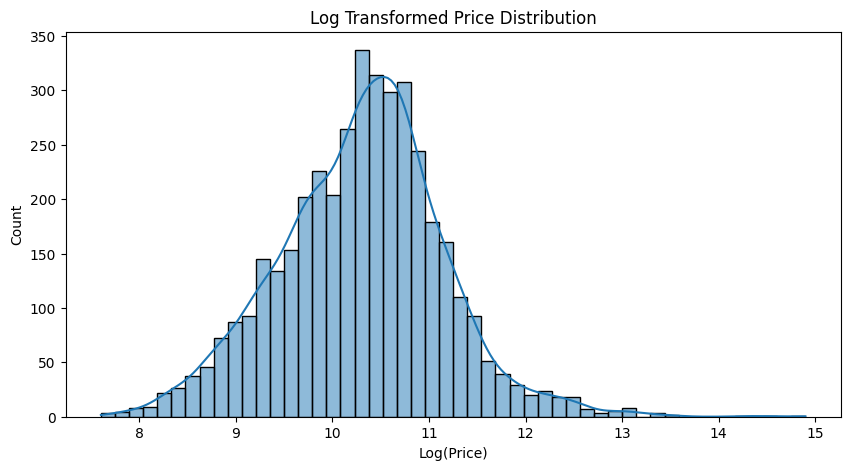

In [45]:
# Create log-transformed target

df_clean["price_log"] = np.log1p(df_clean["price"])

# Check distribution

plt.figure(figsize=(10,5))
sns.histplot(df_clean["price_log"], bins=50, kde=True)

plt.title("Log Transformed Price Distribution")
plt.xlabel("Log(Price)")
plt.ylabel("Count")

plt.show()

In [46]:
print(df_clean["price_log"].describe())

count    4009.000000
mean       10.302401
std         0.850058
min         7.601402
25%         9.752723
50%        10.341775
75%        10.819598
max        14.898699
Name: price_log, dtype: float64


In [47]:
# New target

y_log = df_clean["price_log"]

# Train-test split

X_train, X_test, y_train_log, y_test_log = train_test_split(
    X,
    y_log,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3207, 14)
(802, 14)


In [48]:
rf_log_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=200,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    ))
])

rf_log_pipeline.fit(X_train, y_train_log)

y_pred_log = rf_log_pipeline.predict(X_test)

print("Random Forest (Log Target) Trained Successfully")

Random Forest (Log Target) Trained Successfully


In [49]:
rmse_log = np.sqrt(mean_squared_error(y_test_log, y_pred_log))
r2_log = r2_score(y_test_log, y_pred_log)

print("Random Forest with Log Target")
print("-" * 30)
print("RMSE :", rmse_log)
print("R² Score :", r2_log)

Random Forest with Log Target
------------------------------
RMSE : 0.38068377212029775
R² Score : 0.8138904737030739


In [50]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        objective="reg:squarederror"
    ))
])

# Train
xgb_pipeline.fit(X_train, y_train_log)

# Predict
y_pred_xgb = xgb_pipeline.predict(X_test)

print("XGBoost Trained Successfully")

XGBoost Trained Successfully


In [51]:
rmse_xgb = np.sqrt(mean_squared_error(y_test_log, y_pred_xgb))
r2_xgb = r2_score(y_test_log, y_pred_xgb)

print("XGBoost Results")
print("-" * 30)
print("RMSE :", rmse_xgb)
print("R² Score :", r2_xgb)

XGBoost Results
------------------------------
RMSE : 0.3512630100790375
R² Score : 0.84154545053655


In [52]:
final_comparison = pd.DataFrame({
    "Model": [
        "Random Forest (Original)",
        "Random Forest + Engine",
        "Random Forest + Log Target",
        "XGBoost + Log Target"
    ],
    "R2 Score": [
        r2_rf,
        r2_rf_v2,
        r2_log,
        r2_xgb
    ]
})

final_comparison.sort_values(
    "R2 Score",
    ascending=False
)

,Model,R2 Score
3,XGBoost + Log Target,0.841545
2,Random Forest + Log Target,0.813890
1,Random Forest + Engine,0.127403
0,Random Forest (Original),0.109138


In [53]:
# Features for clustering

cluster_df = df_clean[[
    "price",
    "milage",
    "car_age",
    "horsepower",
    "engine_size"
]].copy()

cluster_df.head()

,price,milage,car_age,horsepower,engine_size
0,10300.0,51000.0,12,300.0,3.7
1,38005.0,34742.0,4,310.0,3.8
2,54598.0,22372.0,3,310.0,3.5
3,15500.0,88900.0,10,354.0,3.5
4,34999.0,9835.0,4,310.0,2.0


In [54]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

cluster_scaled = scaler.fit_transform(cluster_df)

print("Scaled Shape:", cluster_scaled.shape)

Scaled Shape: (4009, 5)


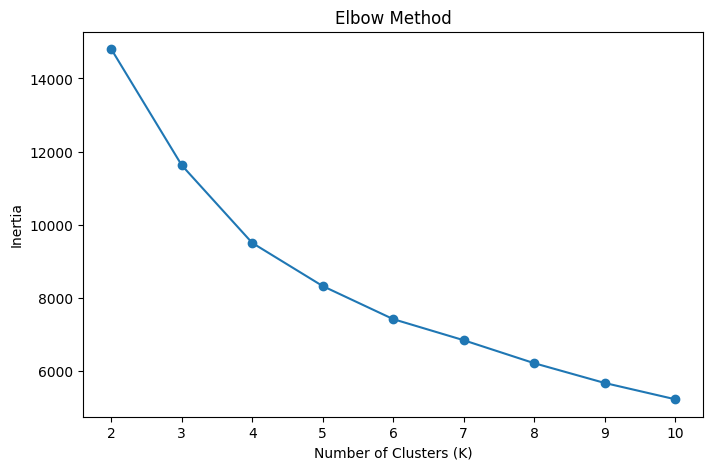

In [55]:
inertia = []

K = range(2, 11)

for k in K:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertia, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

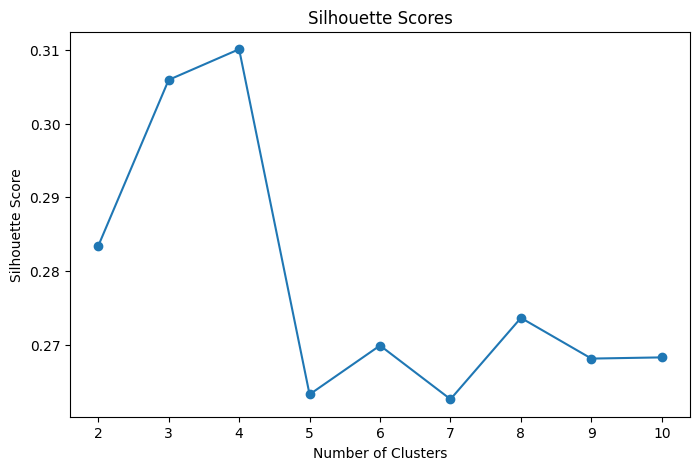

Best K: 4


In [56]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(cluster_scaled)

    score = silhouette_score(
        cluster_scaled,
        labels
    )

    silhouette_scores.append(score)

plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Scores")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")

plt.show()

print(
    "Best K:",
    range(2,11)[np.argmax(silhouette_scores)]
)

In [57]:
# Final KMeans

kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

df_clean["Cluster"] = kmeans.fit_predict(cluster_scaled)

print(df_clean["Cluster"].value_counts())

Cluster
1    1848
0    1160
2     998
3       3
Name: count, dtype: int64


In [58]:
cluster_summary = df_clean.groupby("Cluster")[[
    "price",
    "milage",
    "car_age",
    "horsepower",
    "engine_size"
]].mean()

cluster_summary

,price,milage,car_age,horsepower,engine_size
Cluster,,,,,
0,1.468566e+04,123263.537069,16.480172,267.845690,3.655172
1,4.321421e+04,39451.430195,6.077381,295.675325,2.887906
2,7.536517e+04,43605.196393,7.636273,456.367735,5.206413
3,2.168026e+06,14243.333333,18.000000,436.333333,5.966667


In [59]:
cluster_names = {
    0: "Budget",
    1: "Mid-Range",
    2: "Premium",
    3: "Luxury"
}

df_clean["Segment"] = df_clean["Cluster"].map(cluster_names)

df_clean[["Cluster", "Segment"]].head()

,Cluster,Segment
0,1,Mid-Range
1,1,Mid-Range
2,1,Mid-Range
3,1,Mid-Range
4,1,Mid-Range


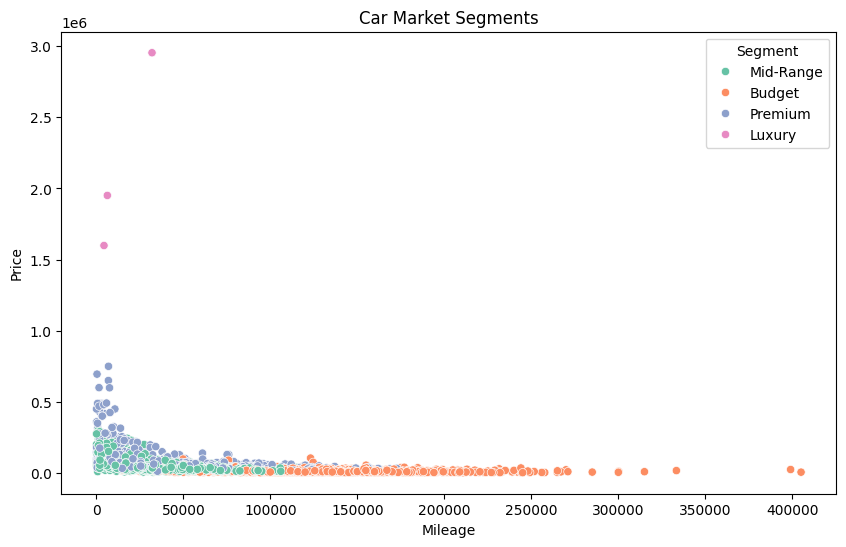

In [60]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_clean,
    x="milage",
    y="price",
    hue="Segment",
    palette="Set2"
)

plt.title("Car Market Segments")
plt.xlabel("Mileage")
plt.ylabel("Price")

plt.show()

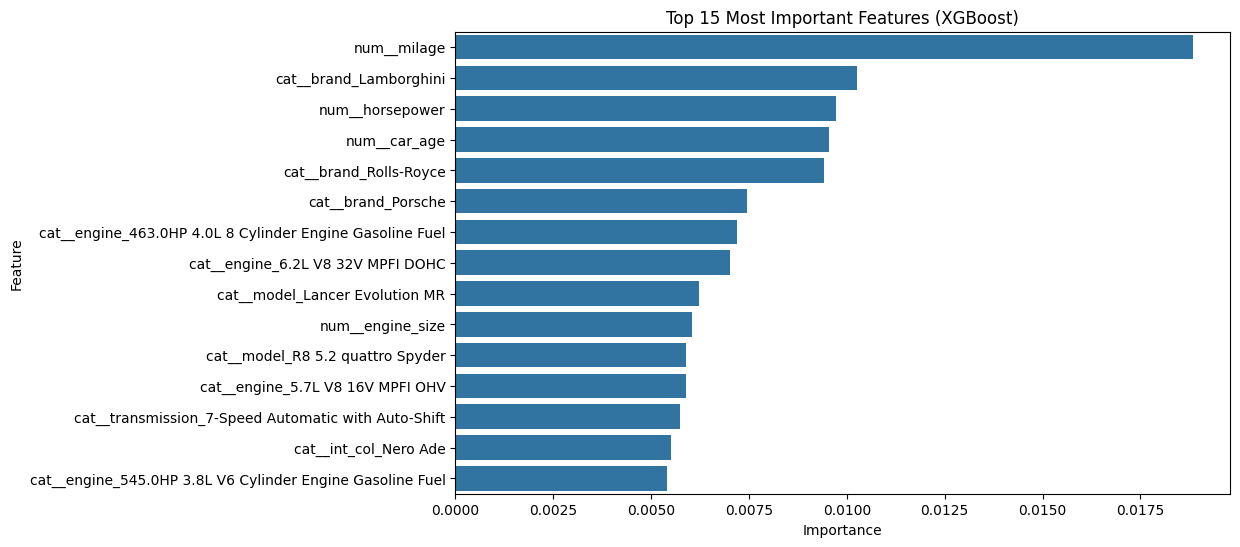

,Feature,Importance
1,num__milage,0.018854
29,cat__brand_Lamborghini,0.010260
3,num__horsepower,0.009727
2,num__car_age,0.009549
50,cat__brand_Rolls-Royce,0.009418
47,cat__brand_Porsche,0.007456
2551,cat__engine_463.0HP 4.0L 8 Cylinder Engine Gas...,0.007192
2670,cat__engine_6.2L V8 32V MPFI DOHC,0.007007
868,cat__model_Lancer Evolution MR,0.006213
4,num__engine_size,0.006043


In [61]:
# Get trained XGBoost model

xgb_model = xgb_pipeline.named_steps["model"]

# Get feature names after preprocessing

feature_names = (
    xgb_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

# Feature importance dataframe

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": xgb_model.feature_importances_
})

# Top 15 important features

top_features = (
    importance_df
    .sort_values("Importance", ascending=False)
    .head(15)
)

# Plot

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Most Important Features (XGBoost)")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

# Display table

top_features

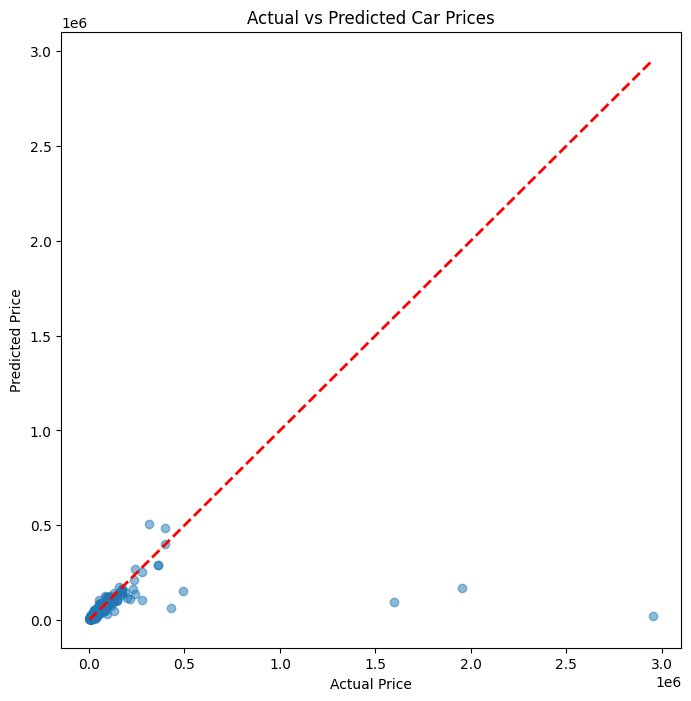

In [62]:
# Convert back to original price scale

actual_price = np.expm1(y_test_log)
predicted_price = np.expm1(y_pred_xgb)

plt.figure(figsize=(8,8))

plt.scatter(
    actual_price,
    predicted_price,
    alpha=0.5
)

# Perfect prediction line

plt.plot(
    [actual_price.min(), actual_price.max()],
    [actual_price.min(), actual_price.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [63]:
results = pd.DataFrame({
    "Actual Price": actual_price,
    "Predicted Price": predicted_price
})

results.head(10)

,Actual Price,Predicted Price
2580,28000.0,28983.240234
3660,5900.0,9901.414062
897,41000.0,42148.789062
2091,40250.0,41609.085938
1044,77999.0,65989.695312
2320,35899.0,35504.257812
465,36000.0,34913.687500
196,47214.0,68782.398438
3113,30900.0,13928.514648
3553,11000.0,8629.213867


In [64]:
from sklearn.decomposition import PCA

# Reduce to 2 dimensions

pca = PCA(n_components=2)

cluster_pca = pca.fit_transform(cluster_scaled)

# Create dataframe

pca_df = pd.DataFrame({
    "PCA1": cluster_pca[:, 0],
    "PCA2": cluster_pca[:, 1],
    "Segment": df_clean["Segment"]
})

pca_df.head()

,PCA1,PCA2,Segment
0,0.364855,-0.058594,Mid-Range
1,-0.652261,-0.614870,Mid-Range
2,-0.894789,-0.911078,Mid-Range
3,0.359155,0.179906,Mid-Range
4,-0.576320,-1.729606,Mid-Range


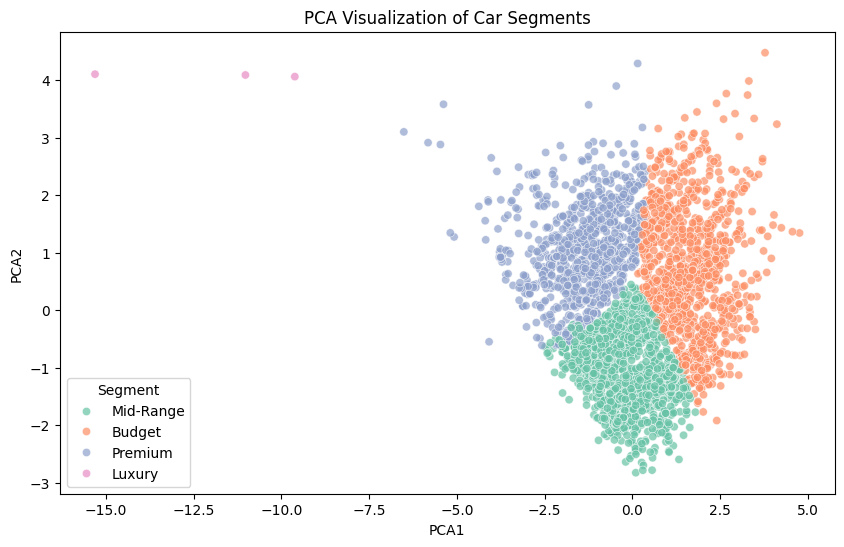

In [65]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Segment",
    palette="Set2",
    alpha=0.7
)

plt.title("PCA Visualization of Car Segments")

plt.show()